We model the following ODE driven by the El Centro Earthquake:
$$
\ddot u(t) + 2\xi\omega_n\,\dot u(t) + \omega_n^{2}u(t)
        = -9.81\,a(t),
\qquad
u(0)=\dot u(0)=0,
$$
where $a(t)$ is the normalized ground-acceleration record, $\xi$ is the damping ratio, and $\omega_n$ is the natural frequency.


In the experiment, we take:
- $\xi = 0.02$
- $T_n = 5\,\mathrm{s}$
- $\omega_n = 2\pi/T_n$
 

## Imports

In [17]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.elcentro import *
print("Using device:", device, "torch", torch.__version__)

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 309.66 KiB | 10.32 MiB/s, done.
From https://github.com/CharliePyle4/BSK_ODE
   75ba980..4dbc9c3  main       -> origin/main
Updating 75ba980..4dbc9c3
Fast-forward
 bsk_ode/elcentro.py                 |   3 -
 experiments/6.1_ElCentro_good.ipynb | 384 ++++++++++++++++++++++++++++++++----
 2 files changed, 343 insertions(+), 44 deletions(-)
Using device: cuda torch 2.11.0+cu128


## Problem and Model Parameters

In [18]:
# Problem Setup
xi = .02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a = -9.81



signature_level = 12
reg_lambda = 1e-3




## Import Forcing and data

In [19]:
import os
os.chdir("/content/BSK_ODE")    # <- adjust if your clone path is different
F_t = pd.read_csv("Data/EQDATA.csv")        # from repo root
t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a * torch.tensor(F_t["F"].values, dtype=torch.float64)
t_start = 0
t_end = 31.18
N = len(F_t)
dt = t_vals[1] - t_vals[0]
F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)


## Run calibration

In [20]:
t_ref, U_ref = solve_linear_ivp(
    x_grid = t_vals,
    forcing_torch = F_vals,
    a = t_start, 
    b = t_end,
    ya = 0, 
    ypa = 0,
    k1 = m, 
    k2 = c,
    k3 = k
    )

U_hat, F_hat, _ = solve_signature_kernel_calibration(
    x=t_vals,        # time grid
    f=F_vals,        # raw forcing (a_g * acceleration)
    k1=m,            # mass
    k2=c,            # damping
    k3=k,            # stiffness
    ua=0.0,          # u(0)
    upa=0.0,         # u'(0)
    depth=signature_level,
    normalize=True,
    reg = reg_lambda
)

non-branched integrated-target loss: 1.871e-03


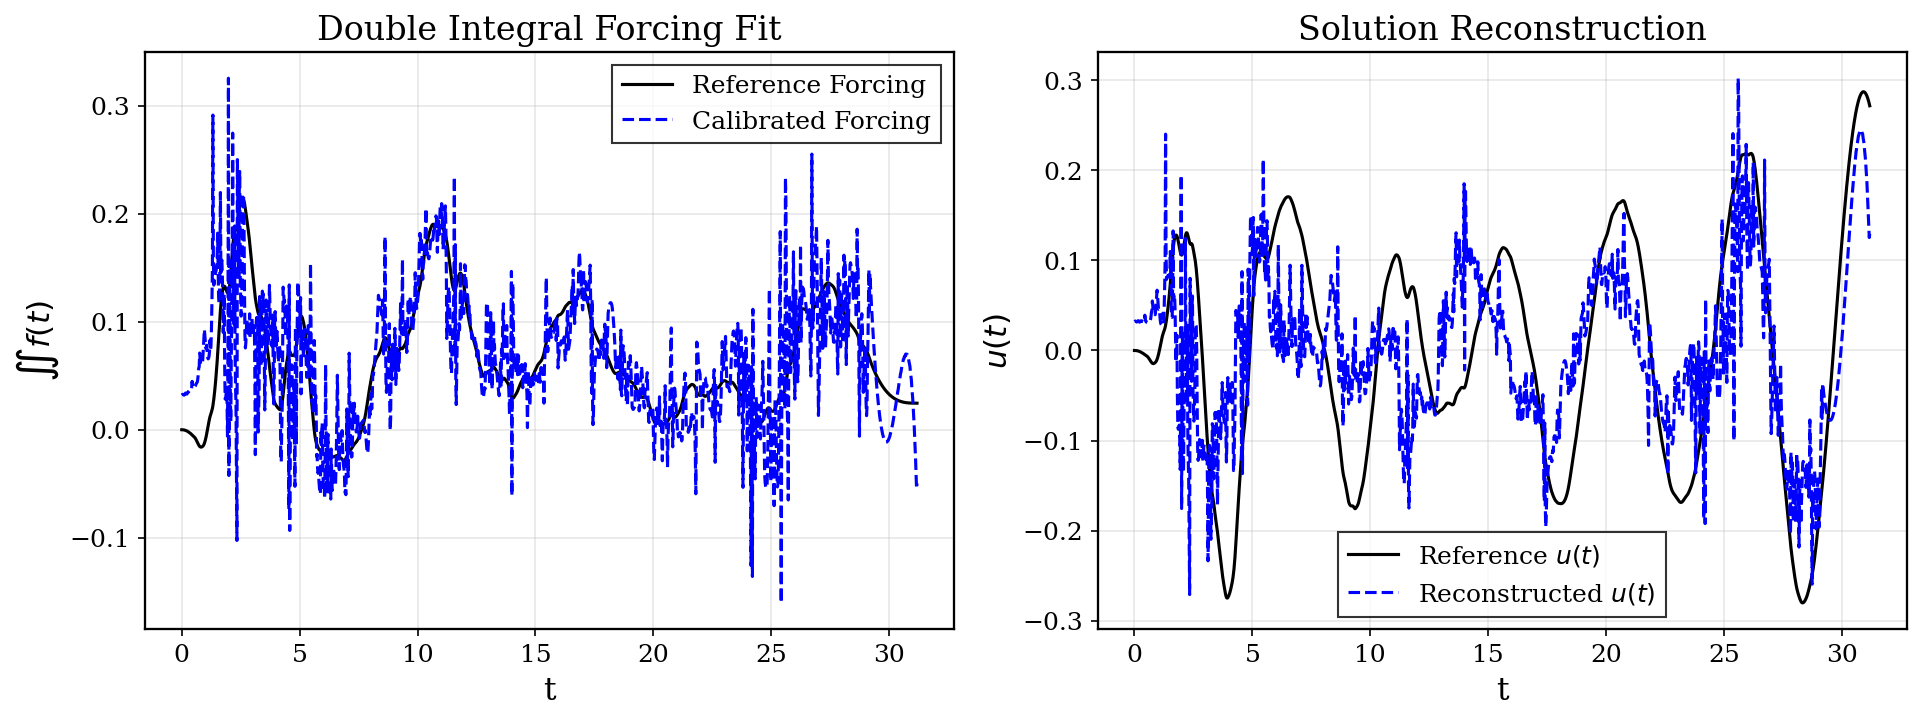


Model Error Summary
Quantity                   Absolute MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------
Forcing F*                 1.871397e-03       2.699014e-01             26.9901%
Solution u(t)              9.739342e-03       5.686409e-01             56.8641%


In [21]:
plot_calibration(t_vals, F_star, F_hat, U_ref, U_hat)
print_errors_calibration(F_hat,F_star,U_hat,U_ref)

# Testing Parameters

In [22]:
TRAIN_FRAC = 0.5  # fraction of grid points used for training
holder_value = .2
reg_lambda = 1e-6

sig_depth_predict = 5
retrain_iters_predict = 5

sig_depth_rolling = 5
retrain_iters_rolling = 5


#Train / Test Split
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
t_train  = t_vals[:N_train]
t_test   = t_vals[N_train:]
f_train  = F_vals[:N_train]     # raw forcing, not F_star
f_test   = F_vals[N_train:]


print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(t_train[0]):.3f}, {float(t_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(t_test[0]):.3f},  {float(t_test[-1]):.3f}])")

Total grid points : 1560
Train points      : 780  (x in [0.000, 15.580])
Test  points      : 780   (x in [15.600,  31.180])


## Prediction and retrain

In [23]:
import time

# ---- prediction with periodic retraining ----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full, f_pred_full = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=True,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method: {elapsed:.3f} seconds")

# ---- prediction with periodic retraining and t lift----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift, f_pred_full_tlift = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=True,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method, tlift: {elapsed:.3f} seconds")



non-branched integrated-target loss: 3.037e-03
non-branched integrated-target loss: 8.972e-03
non-branched integrated-target loss: 6.477e-04
non-branched integrated-target loss: 1.173e-03
non-branched integrated-target loss: 7.605e-02
non-branched integrated-target loss: 1.775e-03
non-branched integrated-target loss: 1.011e-03
non-branched integrated-target loss: 2.872e-02
non-branched integrated-target loss: 8.975e-04
non-branched integrated-target loss: 1.110e-03
non-branched integrated-target loss: 6.365e-04
non-branched integrated-target loss: 1.970e-03
non-branched integrated-target loss: 7.779e-03
non-branched integrated-target loss: 3.169e-03
non-branched integrated-target loss: 1.939e-03
non-branched integrated-target loss: 1.804e-03
non-branched integrated-target loss: 7.347e-04
non-branched integrated-target loss: 7.001e-04
non-branched integrated-target loss: 6.636e-04
non-branched integrated-target loss: 3.840e-03
non-branched integrated-target loss: 1.001e-03
non-branched 

# Evaluate

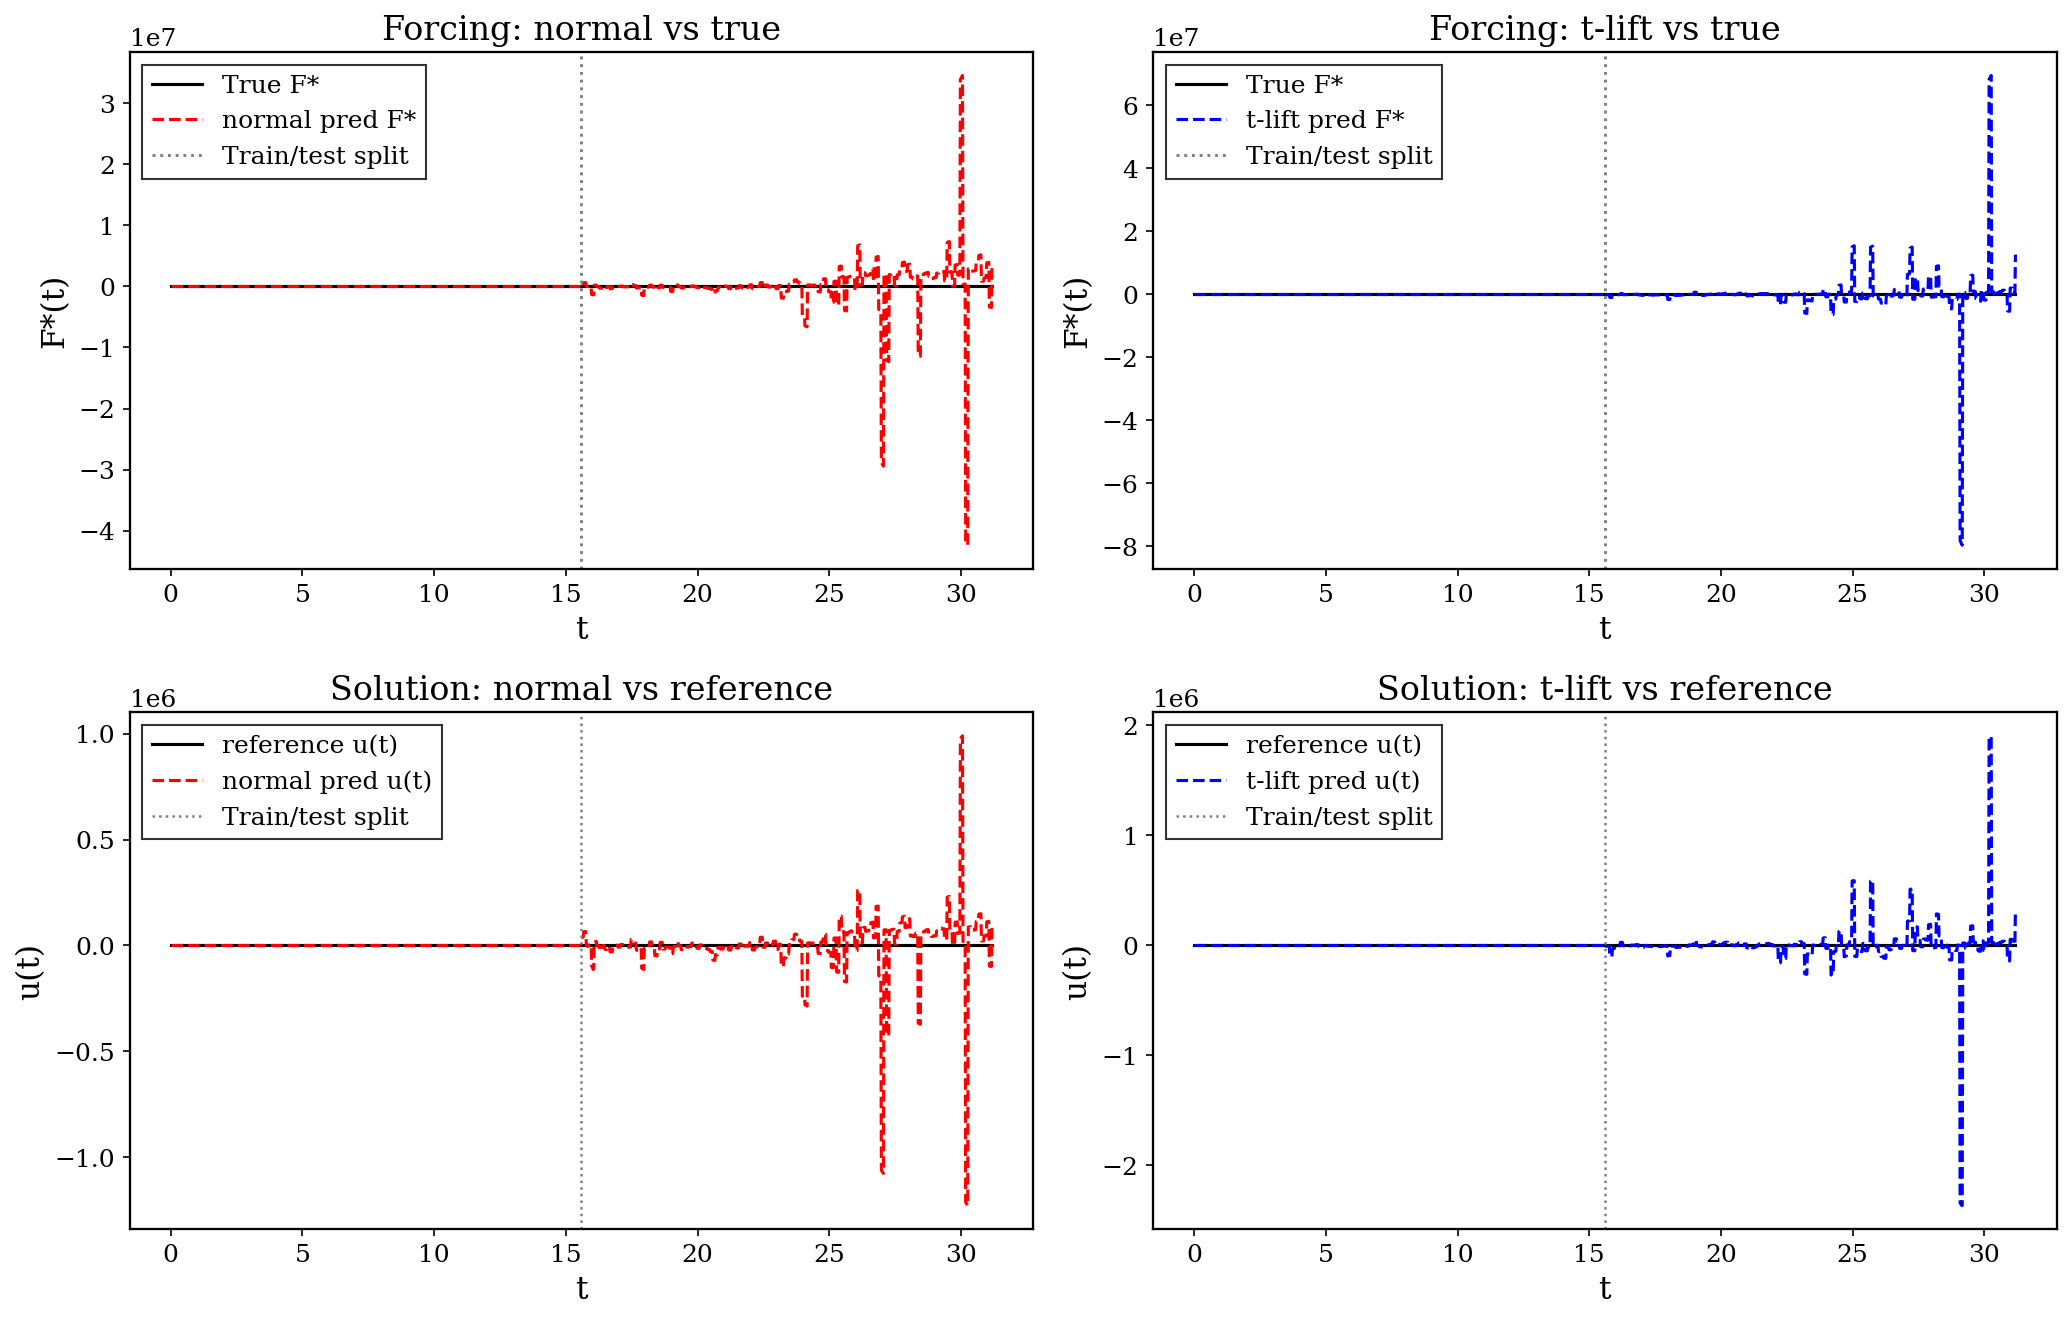


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               3.4289e-01       1.0770e-01         68.59%
Training solution              9.0256e-01       2.7869e-01         69.12%
------------------------------------------------------------------------
Testing forcing                5.8506e+15       1.5556e+16       -165.90%
Testing solution               1.3207e+12       3.0453e+12       -130.57%
------------------------------------------------------------------------
Train+Test forcing             2.1138e+15       5.6205e+15       -165.90%
Train+Test solution            8.6962e+11       2.0051e+12       -130.57%


In [24]:
# 2x2 plots
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

# Relative MSE table
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

## Rolling Retrain

In [25]:
## Rolling Retrain
import time

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_rolling, f_pred_full_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=True,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method: {elapsed:.3f} seconds")

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift_rolling, f_pred_full_tlift_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=True,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method, tlift: {elapsed:.3f} seconds")


non-branched integrated-target loss: 3.037e-03
non-branched integrated-target loss: 8.972e-03


RuntimeError: inconsistent tensor size, expected tensor [784] and src [785] to have the same number of elements, but got 784 and 785 elements respectively

# Results

In [ ]:
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)

# Compare

In [ ]:
# --- Call both ---
print_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)

plot_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)